<div style="background-color:#234c7d; border-radius:8px; padding:32px 40px 24px; margin-bottom:8px;">
  <h1 style="margin:0 0 6px; font-size:28px; font-weight:600; color:#C49A28; letter-spacing:-0.5px;">
    GA Image Approximation
  </h1>
  <p style="margin:0; font-size:13px; color:#a8b8d0; letter-spacing:0.5px;">
    Additional Insights Notebook
  </p>
</div>

<div style="border:1.5px solid #234c7d; border-radius:8px; padding:20px 40px; margin-bottom:8px; display:flex; gap:48px;">
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Group 35 - Convergence</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Alexandra Rodrigues, 20250514 &nbsp;<br>
      Francisca Fernandes, 20250406 &nbsp;<br>
      Gonçalo Arrobas, 20250421 &nbsp;<br>
      Mariana Melo, 20250414  &nbsp;<br>
    </p>
  </div>
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Course</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Computational Intelligence for Optimization<br>
      MSc in Data Science & Advanced Analytics<br>
      Nova Information Management School (NOVA IMS)<br>
      2025/2026
    </p>
  </div>
</div>

## **<span style="color:#234c7d">Table of Contents</span>**

- [1. Introduction](#1-introduction)

- [2. RMSE Heatmap Evolution](#2-rmse-heatmap-evolution)

- [3. Draw Order Significance](#3-draw-order-significance)

- [4. Color Palette Evolution](#4-color-palette-evolution)

- [5. Additional Target Images Experiments](#5-additional-target-images-experiments)
    - [5.1. Exp. 1: Testing with another portrait painting - Mona Lisa](#51-exp-1-testing-with-another-portrait-painting---mona-lisa)
    - [5.2. Exp. 2: Testing with a geometric painting - Nadir Afonso](#52-exp-2-testing-with-a-geometric-painting---nadir-afonso)

In [1]:
import os
import re
import sys
import json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.gridspec as _gs
from matplotlib.colors import Normalize
from scipy import stats as sp_stats
from scipy.ndimage import gaussian_filter
from PIL import Image
from sklearn.cluster import MiniBatchKMeans

sys.path.insert(0, "../src")
from triangle import Triangle
from fitness import RMSEFitness
from ga_utils import render

# 1. Introduction 

This notebook complements the main analysis by exploring aspects of the GA solution that go beyond the standard convergence curves. Rather than focusing on how well the algorithm converged, the sections here ask different questions: where is the error concentrated spatially, does the order in which triangles are drawn actually matter, what color information did the GA encode and how the GA behaves with different target images.

Section 2 traces the spatial distribution of reconstruction error across generations via per-pixel RMSE heatmaps, making it possible to see which regions of the painting the algorithm solved first and which remained hard until the end. Section 3 tests whether the learned triangle ordering carries meaningful information, by comparing the best individual's RMSE against a null distribution of randomly shuffled orderings. Section 4 tracks how the dominant color palette of the rendered image evolves across checkpoints and converges toward the target painting's palette. Section 5 evaluates the generalisation capability of the best configuration by applying it without modification to 2 additional images.

# 2. RMSE Heatmap Evolution

This section visualises **where** the GA is struggling at different points in the run, not just how much error remains overall.

For each selected checkpoint we compute a per-pixel RMSE map against the target - squaring the channel-wise difference, averaging across RGB and taking the square root — then apply a Gaussian blur (sigma = 6) to make spatial structure readable rather than noisy. We sample at generations 0, 100, 500, 2000, 4000, 6000 and 8000, snapping each to the nearest available checkpoint, and always include the final best image. All heatmaps share a common colour scale normalised to the maximum error among the selected checkpoints.

**Interpretation:** bright yellow/white zones = high reconstruction error; dark red/black = low error. The rendered image and its heatmap are shown side by side for each generation, making it possible to watch the algorithm progressively solve the painting region by region.

## 2.1. Heatmap Result

target image: 300x400
found 100 checkpoint files, max gen = 9900
displaying 8 frames: [0, 100, 500, 2000, 4000, 6000, 8000, 9900]
pre-computing heatmaps for global normalisation ...
global max RMSE = 217.72


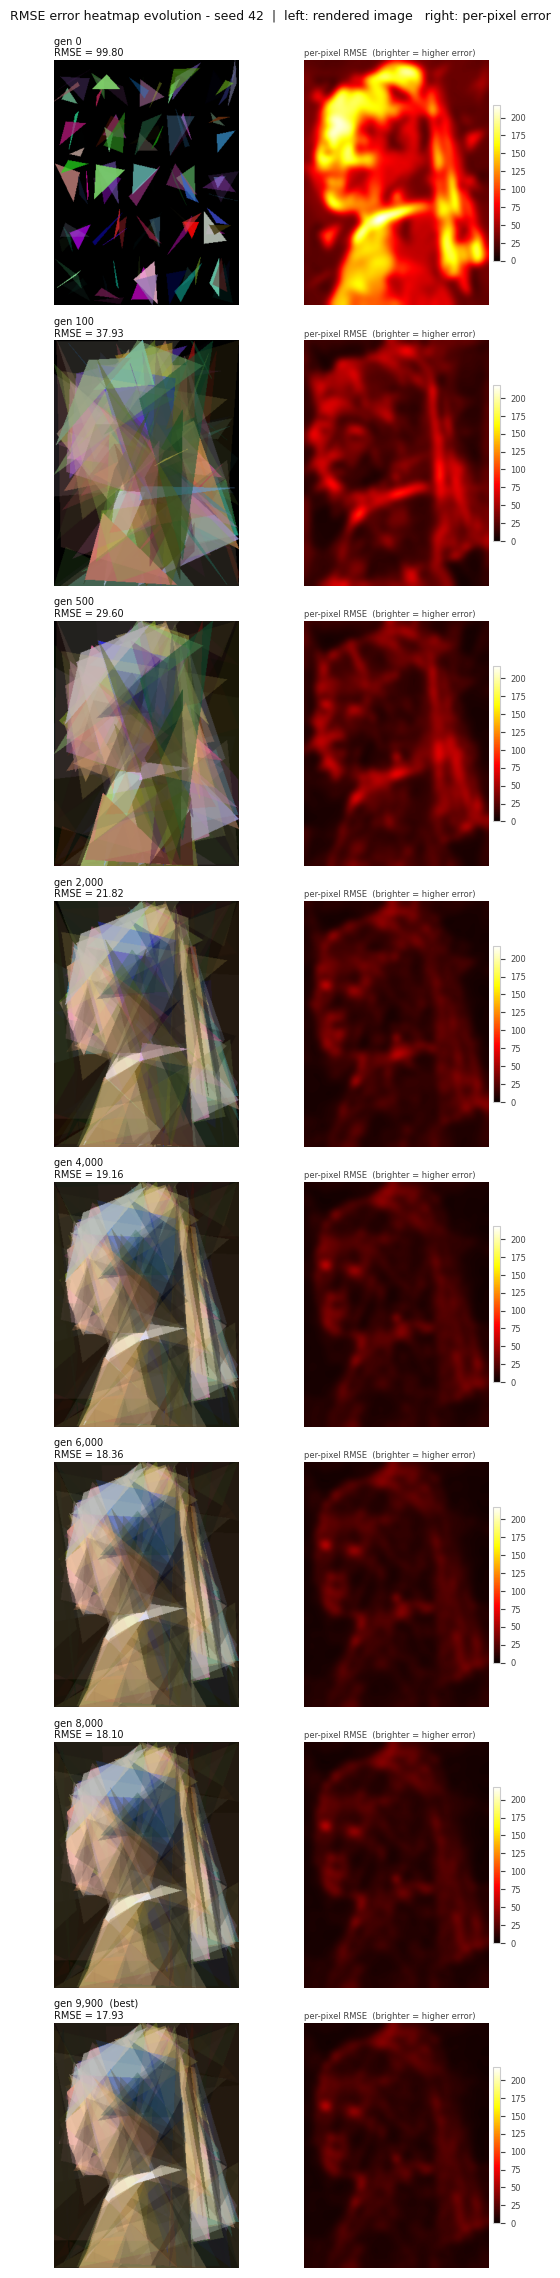

saved: heatmap_evolution.png


In [ ]:
# config
CHECKPOINT_DIR = "../runner_outputs/p12_final_300/seed_42/checkpoints"
TARGET_PATH    = "../data/Girl_Pearl_Earing.png"
BLUR_SIGMA     = 6
CMAP           = "hot"
HEATMAP_FIXED  = [0, 100, 500, 2000, 4000, 6000, 8000]  

# load target
target_img = Image.open(TARGET_PATH).convert("RGB")
target_arr = np.array(target_img, dtype=np.float32)
H, W = target_arr.shape[:2]
print(f"target image: {W}x{H}")

GEN_RE = re.compile(r"(?:gen(?:eration)?[_\-])(\d+)", re.IGNORECASE)

def parse_gen(fname):
    m = GEN_RE.search(fname)
    return int(m.group(1)) if m else None

all_files = [
    f for f in os.listdir(CHECKPOINT_DIR)
    if f.lower().endswith(".png") and parse_gen(f) is not None
]
all_files.sort(key=lambda f: parse_gen(f))

gen_to_file = {parse_gen(f): f for f in all_files}
all_gens    = sorted(gen_to_file.keys())
max_gen     = all_gens[-1]
print(f"found {len(all_gens)} checkpoint files, max gen = {max_gen}")

def nearest_available(target_g, available):
    """Return the available generation closest to target_g."""
    return min(available, key=lambda g: abs(g - target_g))

_seen, selected_gens = set(), []
for tg in HEATMAP_FIXED:
    g = nearest_available(tg, all_gens)
    if g not in _seen:
        selected_gens.append(g)
        _seen.add(g)

g_final = all_gens[-1]
if g_final not in _seen:
    selected_gens.append(g_final)

print(f"displaying {len(selected_gens)} frames: {selected_gens}")

def rmse_heatmap(checkpoint_path):
    """Return a (H, W) heatmap of per-pixel RMSE vs target, blurred for readability."""
    gen_img  = Image.open(checkpoint_path).convert("RGB").resize((W, H))
    gen_arr  = np.array(gen_img, dtype=np.float32)
    sq_err   = np.mean((gen_arr - target_arr) ** 2, axis=2)
    rmse_map = np.sqrt(sq_err)
    return gaussian_filter(rmse_map, sigma=BLUR_SIGMA)

n_frames = len(selected_gens)
fig_h    = 2.8 * n_frames

fig = plt.figure(figsize=(5, fig_h), constrained_layout=True)
BG  = "#ffffff"
FG  = "#111111"
SUB = "#444444"

fig.patch.set_facecolor(BG)

print("pre-computing heatmaps for global normalisation ...")
heatmaps = []
for g in selected_gens:
    path = os.path.join(CHECKPOINT_DIR, gen_to_file[g])
    heatmaps.append(rmse_heatmap(path))

global_max = max(h.max() for h in heatmaps)
norm       = Normalize(vmin=0, vmax=global_max)
print(f"global max RMSE = {global_max:.2f}")

outer = gridspec.GridSpec(
    n_frames, 2, figure=fig,
    wspace=0.01, hspace=0.04,
)

for row_idx, (g, hmap) in enumerate(zip(selected_gens, heatmaps)):
    path     = os.path.join(CHECKPOINT_DIR, gen_to_file[g])
    gen_img  = Image.open(path).convert("RGB").resize((W, H))

    is_last     = (g == max_gen)
    label       = f"gen {g:,}" + ("  (best)" if is_last else "")
    scalar_rmse = float(np.sqrt(np.mean((np.array(gen_img, dtype=np.float32) - target_arr) ** 2)))

    ax_img = fig.add_subplot(outer[row_idx, 0])
    ax_img.imshow(gen_img)
    ax_img.set_title(
        f"{label}\nRMSE = {scalar_rmse:.2f}",
        color=FG, fontsize=7, pad=3, loc="left"
    )
    ax_img.axis("off")

    ax_heat = fig.add_subplot(outer[row_idx, 1])
    im = ax_heat.imshow(hmap, cmap=CMAP, norm=norm)
    ax_heat.set_title(
        "per-pixel RMSE  (brighter = higher error)",
        color=SUB, fontsize=6, pad=3, loc="left"
    )
    ax_heat.axis("off")

    cbar = fig.colorbar(im, ax=ax_heat, fraction=0.035, pad=0.02)
    cbar.ax.tick_params(labelsize=6, colors=SUB)
    cbar.outline.set_edgecolor("#cccccc")

fig.suptitle(
    "RMSE error heatmap evolution - seed 42  |  left: rendered image   right: per-pixel error",
    color=FG, fontsize=9, y=1.01
)

out_path = "heatmap_evolution.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"saved: {out_path}")

## 2.2. Heatmap Analysis 

The heatmaps reveal a clear two-phase convergence pattern. Between gen 0 and gen 500 the RMSE drops sharply (99.80 -> 29.60) and the error map transitions from a high-intensity uniform hot zone to a structured pattern already tracking the face and background regions — the GA is rapidly placing triangles in roughly the right areas and assigning plausible colors. From gen 500 onwards improvement slows considerably, with RMSE declining from 29.60 to 17.93 over the remaining 9,400 generations.

In the later generations the residual error concentrates in the fine-detail regions: the hair and headscarf boundary, the face contour and the dark background edges. These are exactly the areas where a 100-triangle budget is most constrained — sharp colour transitions and fine textures require many small, precisely placed triangles to approximate and the fixed chromosome length limits how much detail can be recovered.

The final heatmap (gen 9,900) shows a relatively uniform dark red across most of the canvas, with the exception of the facial features — particularly the eyes and mouth — where brighter patches persist. These are the highest-frequency regions of the painting, where sharp colours and fine detail exceed what a 100-triangle budget can reproduce.

# 3. Draw Order Significance

The chromosome encodes triangles as an **ordered list**: index 0 is rendered first (bottom layer) and index 99 last (top layer). This ordering is meaningful — a triangle at the top occludes everything beneath it, so the GA must jointly optimise *which* triangles to place *where* and in *what order*.

To test whether the GA actually learned a meaningful draw order (rather than just good colors and positions), we take the best individual's triangle list and generate 200 random permutations of it, re-render each one, and compare the resulting RMSE distribution against the original. The shuffle distribution serves as a null hypothesis: if order were irrelevant, the original should sit somewhere in the middle of it.

**Hypothesis:** if draw order carries information, the original RMSE should sit significantly below the shuffle distribution - any arbitrary reordering should degrade reconstruction quality. We quantify this with a z-score, an empirical p-value (fraction of shuffles that match or beat the original, if none are, this is reported as p < 0.005, the resolution limit of 200 samples) and a parametric p-value assuming the shuffle distribution is approximately normal.

original RMSE: 17.9300
  shuffle 50/200  current RMSE: 46.9024
  shuffle 100/200  current RMSE: 51.0409
  shuffle 150/200  current RMSE: 48.1431
  shuffle 200/200  current RMSE: 48.5626

--- draw order significance ---
shuffle mean RMSE  : 46.8560 +/- 4.5509
original RMSE      : 17.9300
z-score            : -6.356
empirical p-value  : < 0.0050  (0/200 shuffles beat original)
parametric p-value : 1.03e-10  (assumes normal shuffle distribution)
percentile         : 0.0th


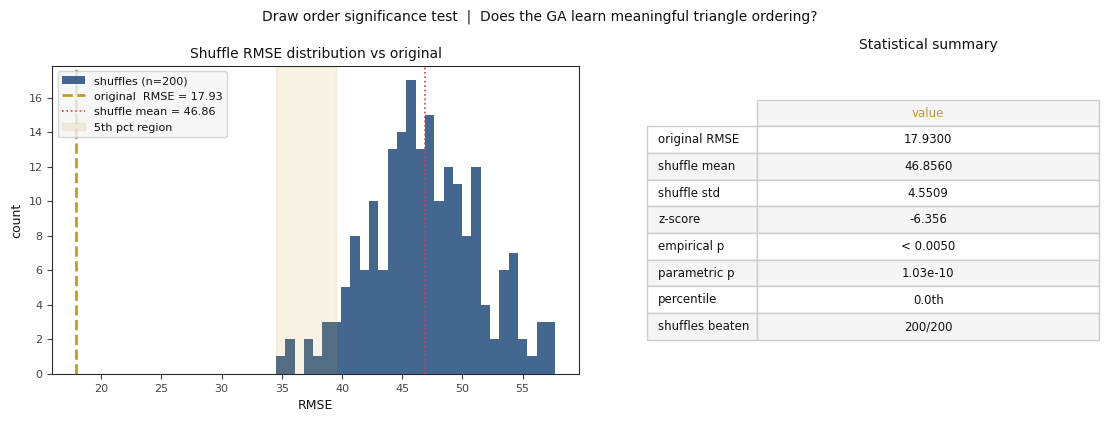

saved: draw_order_significance.png


In [ ]:
# config
TRIANGLES_PATH = "../runner_outputs/p12_final_300/seed_42/best_final_triangles.json"
N_SHUFFLES     = 200   # number of random permutations to sample
RNG_SEED       = 0

BG    = "#ffffff"
GOLD  = "#C49A28"
BLUE  = "#234c7d"
FG    = "#111111"
SUB   = "#444444"

# load triangles and build the best individual
with open(TRIANGLES_PATH) as f:
    tri_data = json.load(f)

fitness_fn     = RMSEFitness(target_arr.astype(np.uint8))
best_triangles = [Triangle.from_dict(t) for t in tri_data]

# original render and RMSE
original_render = render(tuple(best_triangles))
original_rmse   = float(np.sqrt(np.mean((original_render.astype(np.float32) - target_arr) ** 2)))
print(f"original RMSE: {original_rmse:.4f}")

# shuffle experiment
rng = np.random.default_rng(RNG_SEED)
shuffle_rmses = []

for i in range(N_SHUFFLES):
    perm     = rng.permutation(len(best_triangles))
    shuffled = [best_triangles[j] for j in perm]
    rendered = render(tuple(shuffled))
    rmse     = float(np.sqrt(np.mean((rendered.astype(np.float32) - target_arr) ** 2)))
    shuffle_rmses.append(rmse)
    if (i + 1) % 50 == 0:
        print(f"  shuffle {i+1}/{N_SHUFFLES}  current RMSE: {rmse:.4f}")

shuffle_rmses = np.array(shuffle_rmses)

# statistics
sh_mean      = shuffle_rmses.mean()
sh_std       = shuffle_rmses.std()
z_score      = (original_rmse - sh_mean) / sh_std
emp_p        = float(np.mean(shuffle_rmses <= original_rmse))
pct          = float(sp_stats.percentileofscore(shuffle_rmses, original_rmse))
p_parametric = sp_stats.norm.cdf(original_rmse, loc=sh_mean, scale=sh_std)

print(f"\n--- draw order significance ---")
print(f"shuffle mean RMSE  : {sh_mean:.4f} +/- {sh_std:.4f}")
print(f"original RMSE      : {original_rmse:.4f}")
print(f"z-score            : {z_score:.3f}")
print(f"empirical p-value  : < {1/N_SHUFFLES:.4f}  (0/{N_SHUFFLES} shuffles beat original)")
print(f"parametric p-value : {p_parametric:.2e}  (assumes normal shuffle distribution)")
print(f"percentile         : {pct:.1f}th")

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4),
                         gridspec_kw=dict(width_ratios=[2, 1], wspace=0.55))

fig.patch.set_facecolor(BG)
for ax in axes:
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2a2a")

# left: histogram of shuffle RMSEs
ax = axes[0]
ax.hist(shuffle_rmses, bins=30, color=BLUE, alpha=0.85, edgecolor="none", label=f"shuffles (n={N_SHUFFLES})")
ax.axvline(original_rmse, color=GOLD, linewidth=2.0, linestyle="--", label=f"original  RMSE = {original_rmse:.2f}")
ax.axvline(sh_mean,       color="#cc4444", linewidth=1.2, linestyle=":",  label=f"shuffle mean = {sh_mean:.2f}")

p5 = float(np.percentile(shuffle_rmses, 5))
ax.axvspan(shuffle_rmses.min(), p5, alpha=0.12, color=GOLD, label="5th pct region")

ax.set_xlabel("RMSE", color=FG, fontsize=9)
ax.set_ylabel("count", color=FG, fontsize=9)
ax.set_title("Shuffle RMSE distribution vs original", color=FG, fontsize=10)
ax.tick_params(colors=SUB, labelsize=8)
ax.legend(fontsize=8, facecolor="#f5f5f5", edgecolor="#cccccc", labelcolor=FG)

# right: summary stats table 
ax2 = axes[1]
ax2.axis("off")

rows_data = [
    ["metric",           "value"],
    ["original RMSE",    f"{original_rmse:.4f}"],
    ["shuffle mean",     f"{sh_mean:.4f}"],
    ["shuffle std",      f"{sh_std:.4f}"],
    ["z-score",          f"{z_score:.3f}"],
    ["empirical p",      f"< {1/N_SHUFFLES:.4f}"],
    ["parametric p",     f"{p_parametric:.2e}"],
    ["percentile",       f"{pct:.1f}th"],
    ["shuffles beaten",  f"{N_SHUFFLES}/{N_SHUFFLES}"],
]

tbl = ax2.table(
    cellText=[[r[1]] for r in rows_data[1:]],
    rowLabels=[r[0] for r in rows_data[1:]],
    colLabels=[rows_data[0][1]],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.3, 1.6)

for (row_idx, col_idx), cell in tbl.get_celld().items():
    cell.set_facecolor("#f5f5f5" if row_idx % 2 == 0 else "#ffffff")
    cell.set_edgecolor("#cccccc")
    cell.set_text_props(color=GOLD if row_idx == 0 else FG)

ax2.set_title("Statistical summary", color=FG, fontsize=10, pad=12)

fig.suptitle(
    "Draw order significance test  |  Does the GA learn meaningful triangle ordering?",
    color=FG, fontsize=10, y=1.02,
)

out_path = "draw_order_significance.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"saved: {out_path}")

## 3.2. Result Analysis

The results are unambiguous: the original ordering scores an RMSE of 17.93, while all 200 random shuffles score between ~35 and ~58 (mean 46.86, std 4.55), meaning that destroying the learned order consistently more than doubles the reconstruction error. The empirical p-value is < 0.005 (0/200 shuffles matched or beat the original); assuming the shuffle distribution is approximately normal — which the histogram supports — the parametric estimate is p ~ 1e-10, confirming the result is not a sampling artefact.

This makes sense given how triangle rendering works: later triangles are drawn on top of earlier ones, so the order determines which colors are visible in overlapping regions. The GA implicitly learns to sequence triangles such that background-covering triangles come first and detail triangles come last, exploiting occlusion as an additional degree of freedom beyond color and shape alone.

# 4. Color Palette Evolution

As the GA converges, the triangles' colors should progressively align with the target image's dominant palette. This section extracts the **top-K dominant colors** from the rendered checkpoint images at selected generations and compares them against the dominant colors of the original painting.

Colors are extracted via K-Means clustering in RGB space. Each swatch row represents one checkpoint; the rightmost column always shows the target palette for reference. A converging GA should produce palettes that grow visually closer to the target row as generations increase.

> Since clustering is performed in RGB space, the extracted palettes should be interpreted as an approximate description of dominant pixel colours rather than a perceptually exact colour analysis.

## 4.1. Color Palette 

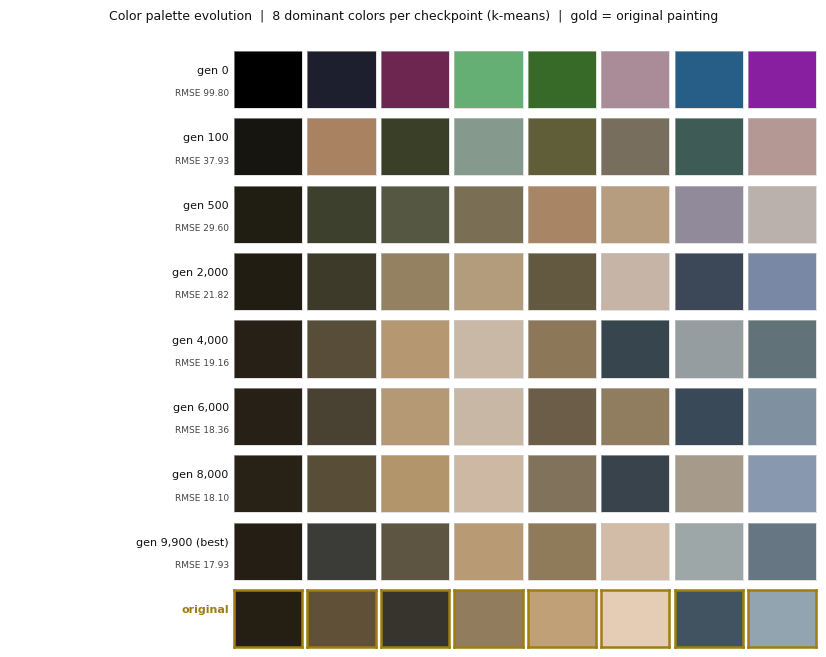

saved: palette_evolution.png


In [4]:
# config
N_COLORS     = 8      # dominant colors per image
SAMPLE_FRAC  = 0.25   # pixel subsample fraction for k-means speed
PALETTE_FIXED = [0, 100, 500, 2000, 4000, 6000, 8000] 

# generation list
try:
    _cd = CHECKPOINT_DIR
    _gt = gen_to_file
    _ag = all_gens
except NameError:
    _GEN_RE = re.compile(r"(?:gen(?:eration)?[_\-])(\d+)", re.IGNORECASE)
    def _pg(f): m = _GEN_RE.search(f); return int(m.group(1)) if m else None
    _fs = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.lower().endswith(".png") and _pg(f)], key=_pg)
    _gt = {_pg(f): f for f in _fs}
    _ag = sorted(_gt)

def _nearest(target_g, available):
    return min(available, key=lambda g: abs(g - target_g))

_seen, palette_gens = set(), []
for tg in PALETTE_FIXED:
    g = _nearest(tg, _ag)
    if g not in _seen:
        palette_gens.append(g)
        _seen.add(g)

g_final = _ag[-1]
if g_final not in _seen:
    palette_gens.append(g_final)

gen_to_file = _gt

# dominant color extraction
def dominant_colors(img_arr: np.ndarray, n: int = N_COLORS) -> np.ndarray:
    """Return (n, 3) uint8 array of dominant RGB colors, sorted by prevalence."""
    pixels   = img_arr.reshape(-1, 3).astype(np.float32)
    n_sample = max(n * 100, int(len(pixels) * SAMPLE_FRAC))
    idx      = np.random.default_rng(0).choice(len(pixels), size=min(n_sample, len(pixels)), replace=False)
    km       = MiniBatchKMeans(n_clusters=n, random_state=0, n_init=5).fit(pixels[idx])
    counts   = np.bincount(km.predict(pixels[idx]), minlength=n)
    order    = np.argsort(-counts)
    return km.cluster_centers_[order].clip(0, 255).astype(np.uint8)

# collect palettes
entries = []

for g in palette_gens:
    arr  = np.array(Image.open(os.path.join(CHECKPOINT_DIR, gen_to_file[g])).convert("RGB").resize((W, H)))
    rmse = float(np.sqrt(np.mean((arr.astype(np.float32) - target_arr) ** 2)))
    entries.append(dict(
        label     = f"gen {g:,}" + (" (best)" if g == palette_gens[-1] else ""),
        palette   = dominant_colors(arr),
        rmse      = rmse,
        is_target = False,
    ))

entries.append(dict(
    label     = "original",
    palette   = dominant_colors(np.array(target_img)),
    rmse      = None,
    is_target = True,
))

# layout
n_rows  = len(entries)
BG      = "#ffffff"
GOLD    = "#a07d10"
SUBTEXT = "#444444"
FG      = "#111111"

fig = plt.figure(figsize=(N_COLORS * 0.7 + 2.8, n_rows * 0.65 + 1.0))
fig.patch.set_facecolor(BG)

gs = _gs.GridSpec(
    n_rows, N_COLORS + 1,
    figure=fig,
    width_ratios=[3.2] + [1] * N_COLORS,
    wspace=0.06,
    hspace=0.18,
    left=0.02, right=0.98,
    top=0.91,  bottom=0.04,
)

for row, entry in enumerate(entries):
    is_tgt  = entry["is_target"]
    palette = entry["palette"]
    label   = entry["label"]
    rmse    = entry["rmse"]

    ax_lbl = fig.add_subplot(gs[row, 0])
    ax_lbl.set_facecolor(BG)
    ax_lbl.axis("off")

    ax_lbl.text(
        1.0, 0.65, label,
        ha="right", va="center", transform=ax_lbl.transAxes,
        fontsize=8, color=GOLD if is_tgt else FG,
        fontweight="bold" if is_tgt else "normal",
    )
    if rmse is not None:
        ax_lbl.text(
            1.0, 0.25, f"RMSE {rmse:.2f}",
            ha="right", va="center", transform=ax_lbl.transAxes,
            fontsize=6.5, color=SUBTEXT,
        )

    for col, rgb in enumerate(palette):
        ax_sw = fig.add_subplot(gs[row, col + 1])
        ax_sw.set_facecolor(rgb / 255.0)
        ax_sw.set_xticks([])
        ax_sw.set_yticks([])
        for spine in ax_sw.spines.values():
            spine.set_edgecolor(GOLD if is_tgt else "#cccccc")
            spine.set_linewidth(1.8 if is_tgt else 0.4)

fig.suptitle(
    f"Color palette evolution  |  {N_COLORS} dominant colors per checkpoint (k-means)  |  "
    "gold = original painting",
    color=FG, fontsize=9, y=0.97,
)

out_path = "palette_evolution.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"saved: {out_path}")

## 4.2. Palette Analysis

At gen 0 the palette is essentially random — saturated greens, purples and magentas that bear no relation to the target — confirming that the initial population is uninformed. By gen 100 the shift is dramatic: warm browns and muted greens already dominate, indicating the GA converges on the correct color space very early in the run.

From gen 500 onwards the palette stabilises into earth tones and dark neutrals that closely mirror the original, and subsequent generations (2000 through 9900) show only incremental refinement. The best individual's palette is visually very close to the original's dominant colors — warm tones and muted blue-greys.

The dominant colors converge fast and early; whether the full color distribution across all 100 triangles follows the same pattern is not captured here, as this analysis reflects only the 8 most prevalent colors per checkpoint.

# 5. Additional Target Images Experiments

This section tests the generalisation capability of our best GA configuration . For computational reasons, the transfer experiments use the same operator configuration selected in the implementation notebook - tournament_k10, blend crossover, gaussian_decay mutation and 3 elites - but with a reduced budget of population size 150 and 3000 generations. This are applied without modification to 2 new target images: a second portrait painting (Mona Lisa) and a geometric painting (from the Portuguese artist Nadir Afonso). The goal is to assess whether the tuned configuration transfers across image types or whether performance is tied to the specific characteristics of the original target.

## 5.1. Exp. 1: Testing with another portrait painting - Mona Lisa

**Target:** *Mona Lisa* by Leonardo da Vinci (resized to 300 $\times$ 400)

The Mona Lisa is one of the most widely used benchmark images in GA-based image approximation, appearing across numerous papers in the field. Testing on this image allows us to assess whether our configuration generalises beyond the original target or whether the tuned hyperparameters are biased toward the specific characteristics of the Girl with a Pearl Earring. It also provides an informal point of comparison with results reported in the literature.

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

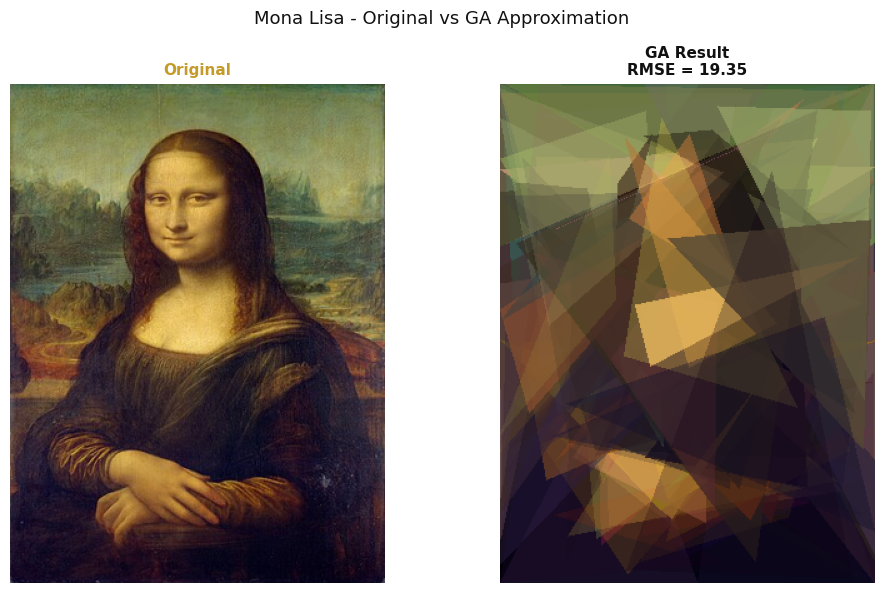

Mona Lisa RMSE: 19.3515


In [ ]:
# Config
MONA_LISA_TARGET = "../data/mona_lisa.png"
MONA_LISA_BEST   = "../runner_outputs/p14_mona_lisa/seed_42/best_final.png"

# Load images
mona_target = np.array(Image.open(MONA_LISA_TARGET).convert("RGB"))
mona_best   = np.array(Image.open(MONA_LISA_BEST).convert("RGB").resize(
                  (mona_target.shape[1], mona_target.shape[0])))

# RMSE
rmse_mona = float(np.sqrt(np.mean((mona_best.astype(float) - mona_target.astype(float))**2)))

# Plot
BG, GOLD, FG = "#ffffff", "#C49A28", "#111111"

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
fig.patch.set_facecolor(BG)

for ax, (img, label) in zip(axes, [(mona_target, "Original"), (mona_best, f"GA Result\nRMSE = {rmse_mona:.2f}")]):
    ax.imshow(img)
    ax.set_title(label, color=GOLD if label == "Original" else FG, fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle("Mona Lisa - Original vs GA Approximation", color=FG, fontsize=13)
plt.tight_layout()
plt.savefig("mona_lisa_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"Mona Lisa RMSE: {rmse_mona:.4f}")

The GA achieves an RMSE of 19.35 on the Mona Lisa using only 100 semi-transparent triangles and 3000 generations - a lower error than on the original target, suggesting the configuration generalises well to portrait paintings with similar structure. 

However, it should be noted that although the RMSE is numerically close to the portrait result, absolute RMSE values across different target images should be compared cautiously, since each image has a different contrast distribution, colour range and structural complexity. The visual result is therefore more informative than the RMSE alone in assessing transfer quality.

Several observations stand out:

- **Color convergence is strong**: the GA correctly identifies the dominant warm skin tones, dark clothing and green-grey background without any image-specific tuning.
- **Large uniform regions are well approximated**: the dark clothing and background landscape are captured accurately, as large triangles can cover these areas efficiently.
- **Fine detail is lost**: facial features (eyes, nose, smile) and the detailed landscape background are not resolved at 100 triangles - the representation is fundamentally limited by the chromosome size, not the operator configuration.
- **Structural silhouette is preserved**: the overall shape of the figure, hair and background regions is recognisable, confirming that the GA learns global structure before local detail.

This result provides preliminary evidence that the tuned configuration transfers reasonably well to another portrait-like target. However, since this experiment uses a single image and a single seed, it should be interpreted as a qualitative transfer test rather than a statistically robust generalisation claim.

## 5.2. Exp. 2: Testing with a geometric painting - Nadir Afonso

**Target:** Geometric composition by Nadir Afonso, Portuguese artist (resized to 300 $\times$ 400)

Since our chromosome representation is built entirely from triangles, we found it particularly interesting to test the GA on a geometric painting. We chose a work by Nadir Afonso, a renowned Portuguese abstract geometric artist, whose compositions are characterised by flat primary colours, hard edges and geometric shapes - triangles, circles and rectangles arranged in structured patterns. Unlike the portrait paintings, this image contains no gradients or soft transitions, which poses a fundamentally different challenge: the GA must approximate sharp colour boundaries and non-triangular shapes (circles, rectangles) using only overlapping semi-transparent triangles.

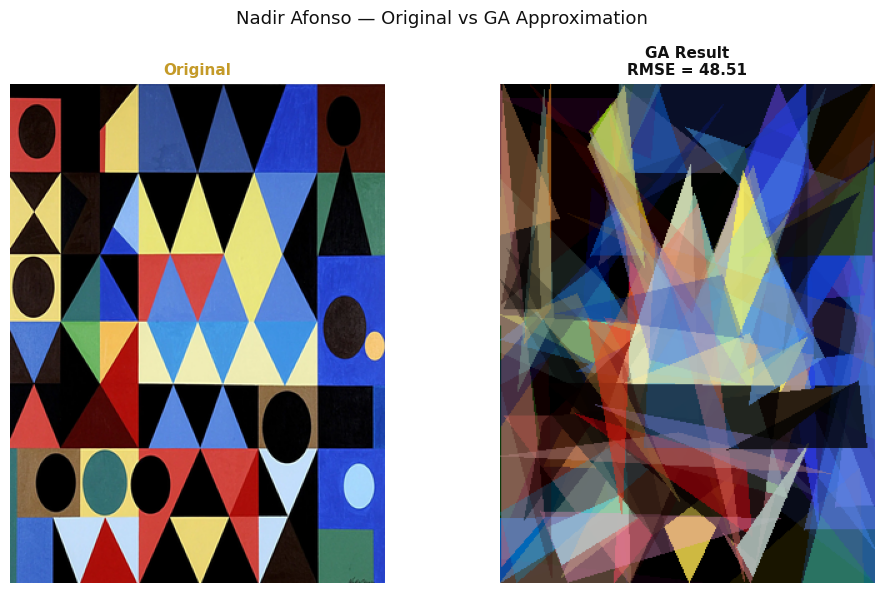

Nadir Afonso RMSE: 48.5071


In [ ]:
NADIR_TARGET = "../data/nadir_afonso.png"
NADIR_BEST   = "../runner_outputs/p14_nadir/seed_42/best_final.png"

nadir_target = np.array(Image.open(NADIR_TARGET).convert("RGB"))
nadir_best   = np.array(Image.open(NADIR_BEST).convert("RGB").resize(
                   (nadir_target.shape[1], nadir_target.shape[0])))

rmse_nadir = float(np.sqrt(np.mean((nadir_best.astype(float) - nadir_target.astype(float))**2)))

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
fig.patch.set_facecolor(BG)

for ax, (img, label) in zip(axes, [(nadir_target, "Original"), (nadir_best, f"GA Result\nRMSE = {rmse_nadir:.2f}")]):
    ax.imshow(img)
    ax.set_title(label, color=GOLD if label == "Original" else FG, fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle("Nadir Afonso — Original vs GA Approximation", color=FG, fontsize=13)
plt.tight_layout()
plt.savefig("nadir_afonso_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"Nadir Afonso RMSE: {rmse_nadir:.4f}")

The GA achieves an RMSE of 48.51 on the Nadir Afonso painting, roughly **2.5 $\times$ higher** than the portrait results. Despite the image appearing, at first glance, geometrically simpler, this outcome is counterintuitive and reveals a fundamental mismatch between the target's visual structure and the chromosome's representational capacity.

Several observations stand out:

- **Hard edges are difficult to approximate with a limited budget of semi-transparent triangles**: the original is built from flat, fully opaque colour regions with sharp boundaries. The GA's triangles are semi-transparent by design, meaning any boundary between two colours requires multiple overlapping layers to approximate - introducing blending artefacts that are penalised heavily by RMSE.
- **Non-triangular primitives cannot be directly encoded**: circles and rectangles, which dominate Nadir Afonso's vocabulary, cannot be expressed as a single triangle. The GA must approximate them with several overlapping triangles, consuming representational budget that would otherwise refine other regions.
- **The colour palette is discrete and precise**: portraits contain gradients and soft transitions where a slightly wrong colour blends in naturally. Here, placing a triangle even slightly off a hard boundary produces a large, visible error, corresponding to a large RMSE contribution.
- **Global structure is partially recovered**: the GA correctly identifies the dominant colour regions - the blue, black, and yellow zones are recognisable - confirming that the optimiser finds the broad palette. However, the structured grid layout and precise placement of shapes are lost entirely.
- **The result resembles a cubist decomposition**: the output is visually coherent as an abstract composition, but is a fundamentally different image, suggesting the GA converged to a local optimum that minimises pixel error globally while failing to reconstruct any individual shape correctly.

The Nadir Afonso result highlights that geometric simplicity in human perception does not imply computational simplicity for a triangle-based GA. Paradoxically, portraits, with their soft gradients and forgiving transitions, are better suited to this representation than hard-edged geometric compositions. Improving performance on this target would require either increasing the triangle budget significantly, reducing or removing transparency or introducing other shapes beyond triangles.